# Supply Chain Performance Analysis

**Objective:** Evaluate product performance, inventory risk, supplier performance, logistics efficiency, quality, and cost drivers using the supplied `supply_chain_data.csv`.

### Business questions
1. Which product categories and SKUs drive revenue?
2. Which suppliers perform best on revenue, quality, lead time, and cost?
3. Which transportation modes, carriers, and routes are most efficient?
4. Where are the major inventory and quality risks?
5. What operational actions should management prioritize?

> **Important:** This dataset contains 100 SKU-level records and no transaction dates, demand history, or explicit units/cost definitions. Therefore, this notebook focuses on descriptive and diagnostic supply-chain analysis rather than forecasting or causal claims.


## 1. Setup & Parameters

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = r"C:\Users\user\Desktop\data analysis\supply_chain_analysis\data\supply_chain_data.csv"
RANDOM_STATE = 42

# Consistent plotting defaults
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")


## 2. Load Data & Initial Validation

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
display(df.head())


Rows: 100
Columns: 24


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,Shipping times,Shipping carriers,Shipping costs,Supplier name,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.81,55,802,"8,662.00",Non-binary,58,7,96,4,Carrier B,2.96,Supplier 3,Mumbai,29,215,29,46.28,Pending,0.23,Road,Route B,187.75
1,skincare,SKU1,14.84,95,736,"7,460.90",Female,53,30,37,2,Carrier A,9.72,Supplier 3,Mumbai,23,517,30,33.62,Pending,4.85,Road,Route B,503.07
2,haircare,SKU2,11.32,34,8,"9,577.75",Unknown,1,10,88,2,Carrier B,8.05,Supplier 1,Mumbai,12,971,27,30.69,Pending,4.58,Air,Route C,141.92
3,skincare,SKU3,61.16,68,83,"7,766.84",Non-binary,23,13,59,6,Carrier C,1.73,Supplier 5,Kolkata,24,937,18,35.62,Fail,4.75,Rail,Route A,254.78
4,skincare,SKU4,4.81,26,871,"2,686.51",Non-binary,5,3,56,8,Carrier A,3.89,Supplier 1,Delhi,5,414,3,92.07,Fail,3.15,Air,Route A,923.44


In [3]:
# Data-quality checks
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100).round(2),
    "unique_values": df.nunique()
})
display(quality)

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate SKUs:", df["SKU"].duplicated().sum())


,dtype,missing_values,missing_pct,unique_values
Product type,str,0,0.00,3
SKU,str,0,0.00,100
Price,float64,0,0.00,100
Availability,int64,0,0.00,63
Number of products sold,int64,0,0.00,96
Revenue generated,float64,0,0.00,100
Customer demographics,str,0,0.00,4
Stock levels,int64,0,0.00,65
Lead times,int64,0,0.00,29
Order quantities,int64,0,0.00,61


Duplicate rows: 0
Duplicate SKUs: 0


## 3. Data Preparation & Derived KPIs

The derived metrics below are designed for diagnosis, not as accounting measures.

- **Total cycle time** = supplier lead time + manufacturing lead time + shipping time.
- **Stock-to-order ratio** = stock level / order quantity; a low value indicates potential replenishment pressure.
- **Revenue per unit** = revenue generated / products sold.
- **Estimated contribution proxy** subtracts the available cost fields from revenue. It should **not** be interpreted as audited gross profit because the dataset does not define the cost fields precisely.


In [4]:
data = df.copy()

data["Revenue_per_Unit"] = (
    data["Revenue generated"] / data["Number of products sold"].replace(0, np.nan)
)

data["Total_Cycle_Time"] = (
    data["Lead time"] +
    data["Manufacturing lead time"] +
    data["Shipping times"]
)

data["Stock_to_Order_Ratio"] = (
    data["Stock levels"] / data["Order quantities"].replace(0, np.nan)
)

data["Estimated_Contribution_Proxy"] = (
    data["Revenue generated"]
    - data["Manufacturing costs"]
    - data["Shipping costs"]
    - data["Costs"]
)

data["Contribution_Proxy_%"] = (
    data["Estimated_Contribution_Proxy"] / data["Revenue generated"] * 100
)

# Risk flags are deliberately simple and transparent.
data["Inventory_Risk"] = np.select(
    [
        data["Stock levels"].eq(0),
        data["Availability"].lt(20),
        data["Stock_to_Order_Ratio"].lt(0.50)
    ],
    ["Stockout", "Low availability", "Low stock vs order"],
    default="Normal"
)

data["Quality_Risk"] = pd.cut(
    data["Defect rates"],
    bins=[-np.inf, 1, 3, np.inf],
    labels=["Low", "Medium", "High"]
)

display(data.head())


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,Shipping times,Shipping carriers,Shipping costs,Supplier name,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs,Revenue_per_Unit,Total_Cycle_Time,Stock_to_Order_Ratio,Estimated_Contribution_Proxy,Contribution_Proxy_%,Inventory_Risk,Quality_Risk
0,haircare,SKU0,69.81,55,802,"8,662.00",Non-binary,58,7,96,4,Carrier B,2.96,Supplier 3,Mumbai,29,215,29,46.28,Pending,0.23,Road,Route B,187.75,10.80,62,0.60,"8,425.01",97.26,Normal,Low
1,skincare,SKU1,14.84,95,736,"7,460.90",Female,53,30,37,2,Carrier A,9.72,Supplier 3,Mumbai,23,517,30,33.62,Pending,4.85,Road,Route B,503.07,10.14,55,1.43,"6,914.50",92.68,Normal,High
2,haircare,SKU2,11.32,34,8,"9,577.75",Unknown,1,10,88,2,Carrier B,8.05,Supplier 1,Mumbai,12,971,27,30.69,Pending,4.58,Air,Route C,141.92,"1,197.22",41,0.01,"9,397.09",98.11,Low stock vs order,High
3,skincare,SKU3,61.16,68,83,"7,766.84",Non-binary,23,13,59,6,Carrier C,1.73,Supplier 5,Kolkata,24,937,18,35.62,Fail,4.75,Rail,Route A,254.78,93.58,48,0.39,"7,474.71",96.24,Low stock vs order,High
4,skincare,SKU4,4.81,26,871,"2,686.51",Non-binary,5,3,56,8,Carrier A,3.89,Supplier 1,Delhi,5,414,3,92.07,Fail,3.15,Air,Route A,923.44,3.08,16,0.09,"1,667.11",62.05,Low stock vs order,High


## 4. Executive KPI Snapshot

In [5]:
kpis = {
    "Total revenue": data["Revenue generated"].sum(),
    "Units sold": data["Number of products sold"].sum(),
    "Average defect rate": data["Defect rates"].mean(),
    "Average total cycle time": data["Total_Cycle_Time"].mean(),
    "Inspection fail rate": (data["Inspection results"].eq("Fail").mean() * 100),
    "SKUs with low availability (<20)": data["Availability"].lt(20).sum(),
    "SKUs with stock/order ratio <0.5": data["Stock_to_Order_Ratio"].lt(0.5).sum(),
    "SKUs with defect rate >3%": data["Defect rates"].gt(3).sum(),
}
for label, value in kpis.items():
    if "revenue" in label.lower():
        print(f"{label:40s}: {value:,.2f}")
    elif "defect" in label.lower():
        print(f"{label:40s}: {value:,.2f}%")
    elif "fail" in label.lower():
        print(f"{label:40s}: {value:,.2f}%")
    elif "time" in label.lower():
        print(f"{label:40s}: {value:,.2f}")
    else:
        print(f"{label:40s}: {value:,.0f}")


Total revenue                           : 577,604.82
Units sold                              : 46,099
Average defect rate                     : 2.28%
Average total cycle time                : 37.60
Inspection fail rate                    : 36.00%
SKUs with low availability (<20)        : 24
SKUs with stock/order ratio <0.5        : 30
SKUs with defect rate >3%               : 32.00%


## 5. Product & SKU Performance

,SKUs,Revenue,Units_Sold,Avg_Price,Avg_Defect,Avg_Cycle_Time,Avg_Availability
Product type,,,,,,,
skincare,40,"241,628.16",20731,47.26,2.33,37.10,50.92
haircare,34,"174,455.39",13611,46.01,2.48,41.38,43.26
cosmetics,26,"161,521.27",11757,57.36,1.92,33.42,51.23


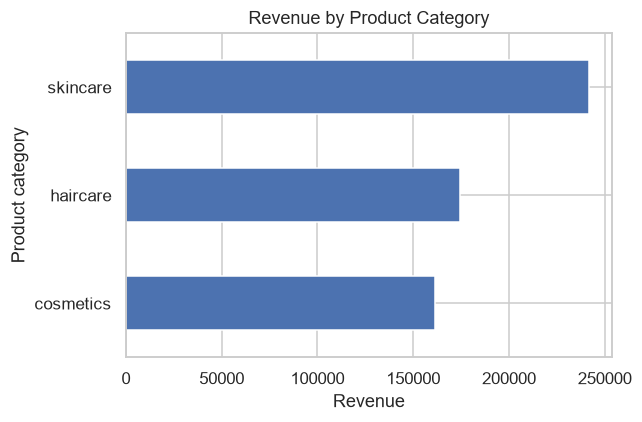

In [6]:
product_summary = (
    data.groupby("Product type")
    .agg(
        SKUs=("SKU", "count"),
        Revenue=("Revenue generated", "sum"),
        Units_Sold=("Number of products sold", "sum"),
        Avg_Price=("Price", "mean"),
        Avg_Defect=("Defect rates", "mean"),
        Avg_Cycle_Time=("Total_Cycle_Time", "mean"),
        Avg_Availability=("Availability", "mean")
    )
    .sort_values("Revenue", ascending=False)
)
display(product_summary.round(2))

fig, ax = plt.subplots()
product_summary["Revenue"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Revenue by Product Category")
ax.set_xlabel("Revenue")
ax.set_ylabel("Product category")
plt.tight_layout()
plt.show()


,SKU,Product type,Revenue generated,Number of products sold,Defect rates,Availability,Supplier name
51,SKU51,haircare,"9,866.47",154,1.77,61,Supplier 5
38,SKU38,cosmetics,"9,692.32",705,0.61,75,Supplier 5
31,SKU31,skincare,"9,655.14",168,2.99,28,Supplier 3
90,SKU90,skincare,"9,592.63",320,1.22,56,Supplier 3
2,SKU2,haircare,"9,577.75",8,4.58,34,Supplier 1
32,SKU32,skincare,"9,571.55",781,1.95,43,Supplier 3
67,SKU67,skincare,"9,473.80",513,0.13,16,Supplier 1
88,SKU88,cosmetics,"9,444.74",737,0.72,58,Supplier 2
52,SKU52,skincare,"9,435.76",820,2.12,1,Supplier 1
18,SKU18,haircare,"9,364.67",620,2.23,23,Supplier 2


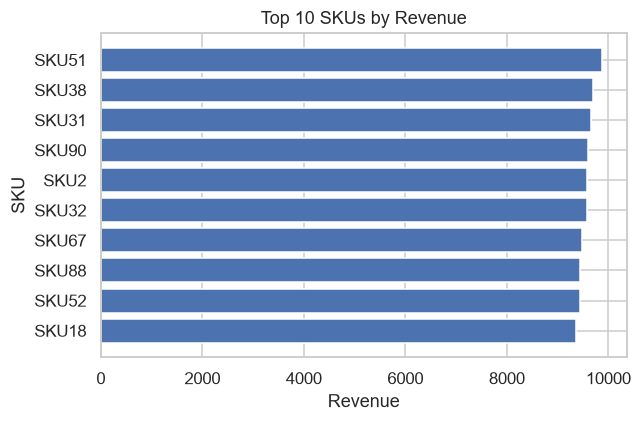

In [7]:
top_skus = (
    data[["SKU", "Product type", "Revenue generated", "Number of products sold",
          "Defect rates", "Availability", "Supplier name"]]
    .sort_values("Revenue generated", ascending=False)
    .head(10)
)
display(top_skus)

fig, ax = plt.subplots()
plot_df = top_skus.sort_values("Revenue generated")
ax.barh(plot_df["SKU"], plot_df["Revenue generated"])
ax.set_title("Top 10 SKUs by Revenue")
ax.set_xlabel("Revenue")
ax.set_ylabel("SKU")
plt.tight_layout()
plt.show()


## 6. Supplier Performance

,SKUs,Revenue,Avg_Defect,Avg_Supplier_Lead_Time,Avg_Manufacturing_Cost,Avg_Cycle_Time,Avg_Availability
Supplier name,,,,,,,
Supplier 1,27,"157,529.00",1.80,14.78,45.25,33.44,46.41
Supplier 2,22,"125,467.42",2.36,18.55,41.62,39.64,39.68
Supplier 5,18,"110,343.46",2.67,18.06,44.77,40.61,52.06
Supplier 3,15,"97,795.98",2.47,20.13,43.63,40.27,48.93
Supplier 4,18,"86,468.96",2.34,15.22,62.71,36.11,57.94


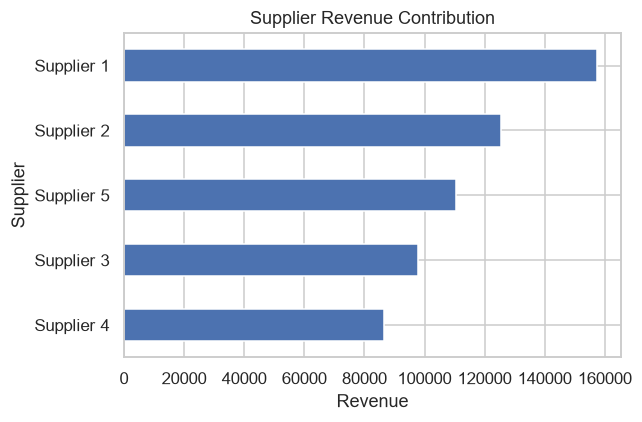

In [8]:
supplier_summary = (
    data.groupby("Supplier name")
    .agg(
        SKUs=("SKU", "count"),
        Revenue=("Revenue generated", "sum"),
        Avg_Defect=("Defect rates", "mean"),
        Avg_Supplier_Lead_Time=("Lead time", "mean"),
        Avg_Manufacturing_Cost=("Manufacturing costs", "mean"),
        Avg_Cycle_Time=("Total_Cycle_Time", "mean"),
        Avg_Availability=("Availability", "mean")
    )
    .sort_values("Revenue", ascending=False)
)
display(supplier_summary.round(2))

fig, ax = plt.subplots()
supplier_summary["Revenue"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Supplier Revenue Contribution")
ax.set_xlabel("Revenue")
ax.set_ylabel("Supplier")
plt.tight_layout()
plt.show()


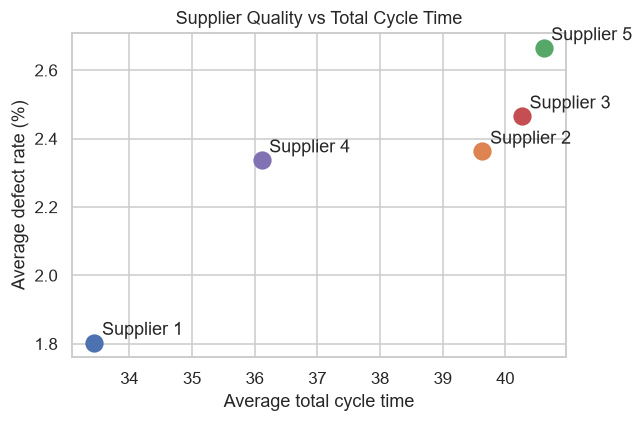

In [9]:
# Supplier comparison: quality vs cycle time
fig, ax = plt.subplots()
for supplier, row in supplier_summary.iterrows():
    ax.scatter(row["Avg_Cycle_Time"], row["Avg_Defect"], s=120)
    ax.annotate(supplier, (row["Avg_Cycle_Time"], row["Avg_Defect"]),
                xytext=(5, 5), textcoords="offset points")
ax.set_title("Supplier Quality vs Total Cycle Time")
ax.set_xlabel("Average total cycle time")
ax.set_ylabel("Average defect rate (%)")
plt.tight_layout()
plt.show()


## 7. Logistics: Carrier, Route & Transportation Mode

In [10]:
carrier_summary = (
    data.groupby("Shipping carriers")
    .agg(
        SKUs=("SKU", "count"),
        Revenue=("Revenue generated", "sum"),
        Avg_Shipping_Time=("Shipping times", "mean"),
        Avg_Shipping_Cost=("Shipping costs", "mean"),
        Avg_Defect=("Defect rates", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

route_summary = (
    data.groupby("Routes")
    .agg(
        SKUs=("SKU", "count"),
        Revenue=("Revenue generated", "sum"),
        Avg_Shipping_Time=("Shipping times", "mean"),
        Avg_Shipping_Cost=("Shipping costs", "mean"),
        Avg_Defect=("Defect rates", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

mode_summary = (
    data.groupby("Transportation modes")
    .agg(
        SKUs=("SKU", "count"),
        Revenue=("Revenue generated", "sum"),
        Avg_Shipping_Time=("Shipping times", "mean"),
        Avg_Shipping_Cost=("Shipping costs", "mean"),
        Avg_Defect=("Defect rates", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

display(carrier_summary.round(2))
display(route_summary.round(2))
display(mode_summary.round(2))


,SKUs,Revenue,Avg_Shipping_Time,Avg_Shipping_Cost,Avg_Defect
Shipping carriers,,,,,
Carrier B,43,"250,094.65",5.30,5.51,1.76
Carrier C,29,"184,880.18",6.03,5.60,2.60
Carrier A,28,"142,629.99",6.14,5.55,2.74


,SKUs,Revenue,Avg_Shipping_Time,Avg_Shipping_Cost,Avg_Defect
Routes,,,,,
Route A,43,"253,198.85",6.02,5.38,2.34
Route B,37,"204,484.01",5.70,5.55,2.32
Route C,20,"119,921.96",5.25,5.90,2.05


,SKUs,Revenue,Avg_Shipping_Time,Avg_Shipping_Cost,Avg_Defect
Transportation modes,,,,,
Rail,28,"164,990.42",6.57,5.47,2.32
Road,29,"159,315.23",4.72,5.54,2.62
Air,26,"155,735.35",5.12,6.02,1.82
Sea,17,"97,563.82",7.12,4.97,2.32


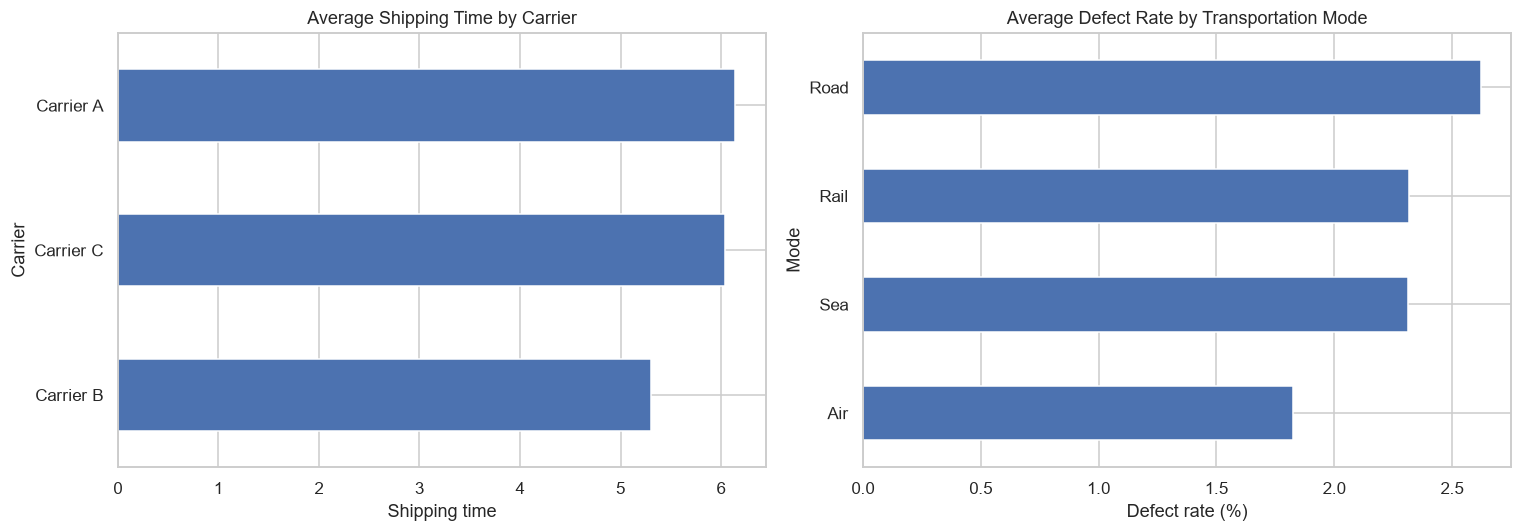

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

carrier_summary["Avg_Shipping_Time"].sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Average Shipping Time by Carrier")
axes[0].set_xlabel("Shipping time")
axes[0].set_ylabel("Carrier")

mode_summary["Avg_Defect"].sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Average Defect Rate by Transportation Mode")
axes[1].set_xlabel("Defect rate (%)")
axes[1].set_ylabel("Mode")

plt.tight_layout()
plt.show()


## 8. Inventory Risk

,SKU_Count,Share_%
Risk,,
Normal,49,49.00
Low stock vs order,26,26.00
Low availability,24,24.00
Stockout,1,1.00


Inventory_Risk,Low availability,Low stock vs order,Normal,Stockout
Product type,,,,
cosmetics,23.10,23.10,53.80,0.00
haircare,26.50,17.60,52.90,2.90
skincare,22.50,35.00,42.50,0.00


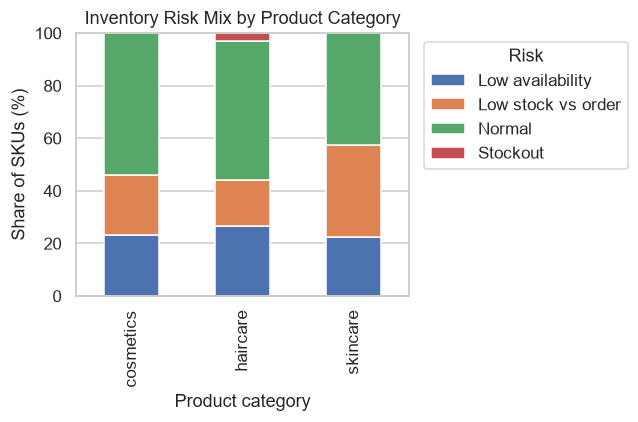

In [12]:
inventory_summary = (
    data["Inventory_Risk"]
    .value_counts()
    .rename_axis("Risk")
    .to_frame("SKU_Count")
)
inventory_summary["Share_%"] = inventory_summary["SKU_Count"] / len(data) * 100
display(inventory_summary.round(2))

risk_by_product = pd.crosstab(
    data["Product type"], data["Inventory_Risk"], normalize="index"
).mul(100).round(1)
display(risk_by_product)

fig, ax = plt.subplots()
risk_by_product.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Inventory Risk Mix by Product Category")
ax.set_xlabel("Product category")
ax.set_ylabel("Share of SKUs (%)")
ax.legend(title="Risk", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 9. Quality & Inspection Analysis

,SKUs,Revenue,Avg_Defect,Avg_Cost
Inspection results,,,,
Pending,41,"255,729.54",2.15,520.47
Fail,36,"190,565.53",2.57,511.39
Pass,23,"131,309.75",2.04,572.84


,Avg_Defect,High_Risk_SKUs,Failed_Inspections,SKUs
Supplier name,,,,
Supplier 1,1.80,7,6,27
Supplier 4,2.34,6,12,18
Supplier 2,2.36,7,8,22
Supplier 3,2.47,5,3,15
Supplier 5,2.67,7,7,18


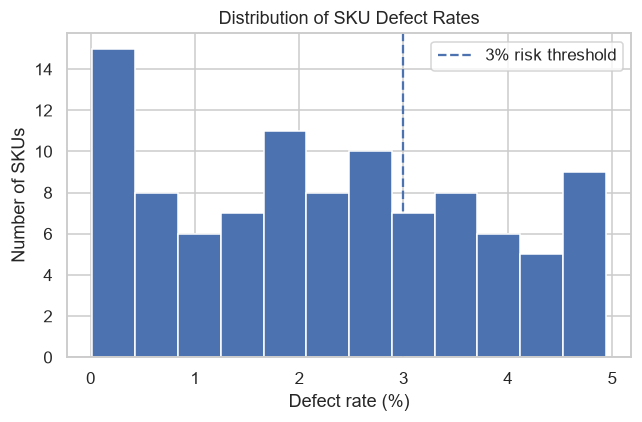

In [13]:
inspection_summary = (
    data.groupby("Inspection results")
    .agg(
        SKUs=("SKU", "count"),
        Revenue=("Revenue generated", "sum"),
        Avg_Defect=("Defect rates", "mean"),
        Avg_Cost=("Costs", "mean")
    )
    .sort_values("SKUs", ascending=False)
)
display(inspection_summary.round(2))

quality_supplier = (
    data.groupby("Supplier name")
    .agg(
        Avg_Defect=("Defect rates", "mean"),
        High_Risk_SKUs=("Quality_Risk", lambda s: (s == "High").sum()),
        Failed_Inspections=("Inspection results", lambda s: (s == "Fail").sum()),
        SKUs=("SKU", "count")
    )
    .sort_values("Avg_Defect")
)
display(quality_supplier.round(2))

fig, ax = plt.subplots()
ax.hist(data["Defect rates"], bins=12)
ax.axvline(3, linestyle="--", label="3% risk threshold")
ax.set_title("Distribution of SKU Defect Rates")
ax.set_xlabel("Defect rate (%)")
ax.set_ylabel("Number of SKUs")
ax.legend()
plt.tight_layout()
plt.show()


## 10. Location Analysis

,SKUs,Revenue,Avg_Defect,Avg_Cycle_Time,Avg_Shipping_Cost,Avg_Availability
Location,,,,,,
Mumbai,22,"137,755.03",2.12,40.59,6.25,44.09
Kolkata,25,"137,077.55",2.29,40.40,5.76,40.84
Chennai,20,"119,142.82",2.64,37.30,4.69,54.80
Bangalore,18,"102,601.72",2.09,33.33,5.75,56.22
Delhi,15,"81,027.70",2.23,34.07,5.07,49.40


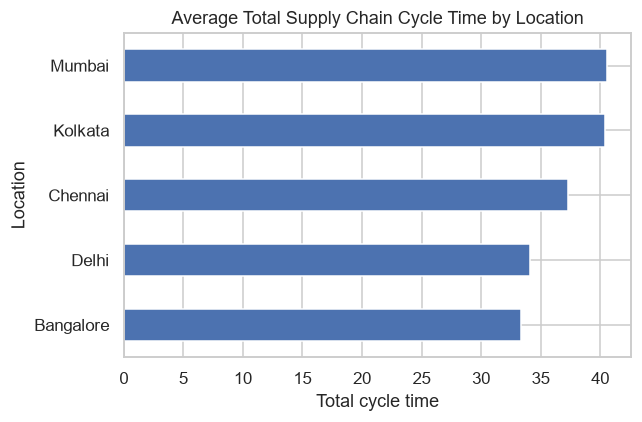

In [14]:
location_summary = (
    data.groupby("Location")
    .agg(
        SKUs=("SKU", "count"),
        Revenue=("Revenue generated", "sum"),
        Avg_Defect=("Defect rates", "mean"),
        Avg_Cycle_Time=("Total_Cycle_Time", "mean"),
        Avg_Shipping_Cost=("Shipping costs", "mean"),
        Avg_Availability=("Availability", "mean")
    )
    .sort_values("Revenue", ascending=False)
)
display(location_summary.round(2))

fig, ax = plt.subplots()
location_summary["Avg_Cycle_Time"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Average Total Supply Chain Cycle Time by Location")
ax.set_xlabel("Total cycle time")
ax.set_ylabel("Location")
plt.tight_layout()
plt.show()


## 11. Relationship & Driver Analysis

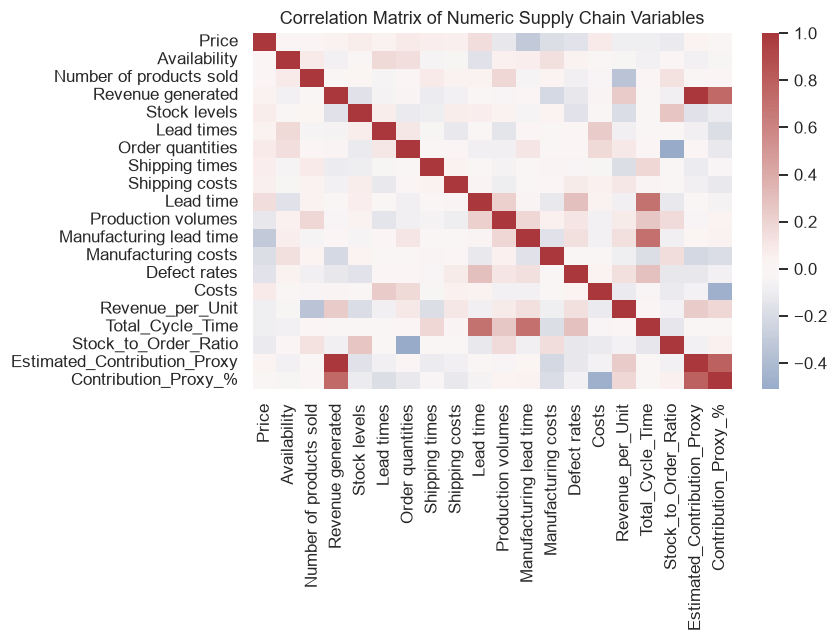

,Correlation with Revenue
Estimated_Contribution_Proxy,1.00
Contribution_Proxy_%,0.74
Revenue_per_Unit,0.23
Manufacturing costs,-0.21
Stock levels,-0.16
Defect rates,-0.13
Shipping times,-0.11
Stock_to_Order_Ratio,-0.08
Availability,-0.08
Shipping costs,-0.07


In [15]:
numeric_cols = data.select_dtypes(include=np.number).columns
corr = data[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap="vlag", center=0, annot=False)
plt.title("Correlation Matrix of Numeric Supply Chain Variables")
plt.tight_layout()
plt.show()

revenue_corr = (
    corr["Revenue generated"]
    .drop("Revenue generated")
    .sort_values(key=abs, ascending=False)
)
display(revenue_corr.to_frame("Correlation with Revenue"))


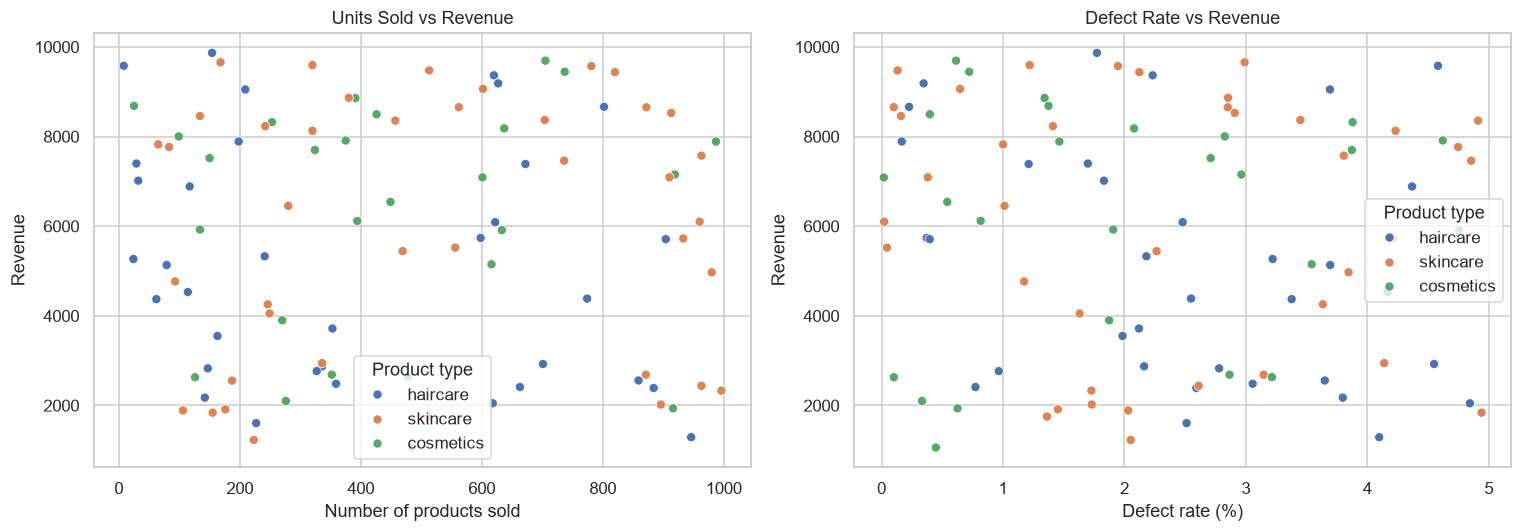

In [16]:
# Direct operational relationships
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=data, x="Number of products sold", y="Revenue generated",
    hue="Product type", ax=axes[0]
)
axes[0].set_title("Units Sold vs Revenue")
axes[0].set_xlabel("Number of products sold")
axes[0].set_ylabel("Revenue")

sns.scatterplot(
    data=data, x="Defect rates", y="Revenue generated",
    hue="Product type", ax=axes[1]
)
axes[1].set_title("Defect Rate vs Revenue")
axes[1].set_xlabel("Defect rate (%)")
axes[1].set_ylabel("Revenue")

plt.tight_layout()
plt.show()


## 12. Prioritization: High-Value but High-Risk SKUs

In [17]:
# Flag SKUs that combine meaningful revenue with operational risk.
revenue_cutoff = data["Revenue generated"].median()

priority_skus = data[
    (data["Revenue generated"] >= revenue_cutoff) &
    (
        data["Defect rates"].gt(3) |
        data["Availability"].lt(20) |
        data["Stock_to_Order_Ratio"].lt(0.5)
    )
].copy()

priority_skus = priority_skus.sort_values(
    ["Revenue generated", "Defect rates"], ascending=[False, False]
)

priority_cols = [
    "SKU", "Product type", "Revenue generated", "Availability",
    "Stock levels", "Order quantities", "Stock_to_Order_Ratio",
    "Defect rates", "Inspection results", "Supplier name",
    "Transportation modes", "Routes"
]
display(priority_skus[priority_cols].round(2))
print(f"Priority SKUs identified: {len(priority_skus)}")


,SKU,Product type,Revenue generated,Availability,Stock levels,Order quantities,Stock_to_Order_Ratio,Defect rates,Inspection results,Supplier name,Transportation modes,Routes
31,SKU31,skincare,"9,655.14",28,6,44,0.14,2.99,Pending,Supplier 3,Rail,Route C
2,SKU2,haircare,"9,577.75",34,1,88,0.01,4.58,Pending,Supplier 1,Air,Route C
67,SKU67,skincare,"9,473.80",16,12,71,0.17,0.13,Pass,Supplier 1,Sea,Route C
52,SKU52,skincare,"9,435.76",1,64,11,5.82,2.12,Pending,Supplier 1,Air,Route C
18,SKU18,haircare,"9,364.67",23,10,46,0.22,2.23,Pending,Supplier 2,Sea,Route A
99,SKU99,haircare,"9,185.19",17,55,59,0.93,0.35,Fail,Supplier 2,Rail,Route B
34,SKU34,skincare,"9,061.71",96,1,21,0.05,0.65,Pass,Supplier 1,Road,Route B
24,SKU24,haircare,"9,049.08",32,4,2,2.00,3.69,Pending,Supplier 2,Air,Route A
60,SKU60,skincare,"8,864.08",16,41,72,0.57,2.85,Fail,Supplier 4,Rail,Route A
85,SKU85,cosmetics,"8,684.61",83,15,66,0.23,1.37,Fail,Supplier 5,Road,Route B


Priority SKUs identified: 32


## 13. Automated Business Findings

In [18]:
top_product = product_summary["Revenue"].idxmax()
top_supplier = supplier_summary["Revenue"].idxmax()
lowest_defect_supplier = supplier_summary["Avg_Defect"].idxmin()
fastest_mode = mode_summary["Avg_Shipping_Time"].idxmin()
lowest_defect_mode = mode_summary["Avg_Defect"].idxmin()
highest_revenue_carrier = carrier_summary["Revenue"].idxmax()
high_defect_count = data["Defect rates"].gt(3).sum()
low_availability_count = data["Availability"].lt(20).sum()
low_stock_ratio_count = data["Stock_to_Order_Ratio"].lt(0.5).sum()

findings = f'''
### Key findings

- **Revenue concentration:** {top_product.title()} is the highest-revenue product category, generating **{product_summary.loc[top_product, "Revenue"]:,.0f}**.
- **Supplier scale:** {top_supplier} contributes the most revenue at **{supplier_summary.loc[top_supplier, "Revenue"]:,.0f}**.
- **Supplier quality:** {lowest_defect_supplier} has the lowest average defect rate at **{supplier_summary.loc[lowest_defect_supplier, "Avg_Defect"]:.2f}%**.
- **Logistics:** {fastest_mode} has the shortest average shipping time at **{mode_summary.loc[fastest_mode, "Avg_Shipping_Time"]:.2f}**, while {lowest_defect_mode} has the lowest average defect rate among transportation modes at **{mode_summary.loc[lowest_defect_mode, "Avg_Defect"]:.2f}%**.
- **Carrier concentration:** {highest_revenue_carrier} handles the largest revenue share in this sample, with **{carrier_summary.loc[highest_revenue_carrier, "Revenue"]:,.0f}** of revenue.
- **Quality risk:** **{high_defect_count} of {len(data)} SKUs ({high_defect_count/len(data)*100:.1f}%)** have defect rates above 3%.
- **Inventory risk:** **{low_availability_count} SKUs** have availability below 20, and **{low_stock_ratio_count} SKUs** have stock levels below half of their order quantity.
- **Inspection:** **{(data["Inspection results"]=="Fail").mean()*100:.1f}%** of records are marked as failed inspections, while **{(data["Inspection results"]=="Pending").mean()*100:.1f}%** remain pending.
'''
display(Markdown(findings))




### Key findings

- **Revenue concentration:** Skincare is the highest-revenue product category, generating **241,628**.
- **Supplier scale:** Supplier 1 contributes the most revenue at **157,529**.
- **Supplier quality:** Supplier 1 has the lowest average defect rate at **1.80%**.
- **Logistics:** Road has the shortest average shipping time at **4.72**, while Air has the lowest average defect rate among transportation modes at **1.82%**.
- **Carrier concentration:** Carrier B handles the largest revenue share in this sample, with **250,095** of revenue.
- **Quality risk:** **32 of 100 SKUs (32.0%)** have defect rates above 3%.
- **Inventory risk:** **24 SKUs** have availability below 20, and **30 SKUs** have stock levels below half of their order quantity.
- **Inspection:** **36.0%** of records are marked as failed inspections, while **41.0%** remain pending.


## 14. Recommendations

### 1. Prioritize high-value, high-risk SKUs
Use the priority table to focus inventory and quality actions on SKUs that combine high revenue with low availability, low stock relative to orders, or elevated defect rates.

### 2. Investigate supplier quality variation
Compare suppliers on defect rate and cycle time rather than revenue alone. A supplier with high revenue contribution but elevated defects may require corrective action, tighter incoming inspection, or supplier-development work.

### 3. Review transportation-mode trade-offs
Do not optimize for shipping speed alone. Compare shipping time, shipping cost, and defect rate together. The best mode depends on the service level required for each product.

### 4. Reduce inventory blind spots
The dataset has no historical demand series, so true safety stock or reorder points cannot be calculated. For production use, add daily/weekly demand, demand variability, supplier reliability, and service-level targets.

### 5. Resolve inspection backlog
Pending inspections represent an operational information gap. Prioritize pending SKUs with high revenue, high defect rates, or low availability so decisions are based on current quality status.

### 6. Improve the next version of the dataset
For stronger supply-chain analytics, add transaction dates, demand/forecast history, purchase-order status, promised vs actual delivery dates, inventory movements, supplier SLA metrics, and clearly defined cost fields.


## 15. Conclusion

This analysis provides a portfolio-ready diagnostic view of the supply chain: **revenue performance → suppliers → logistics → inventory → quality → risk prioritization**.

The strongest next step is to turn the identified risks into an operational dashboard with filters for product, supplier, location, carrier, transportation mode, and route. Forecasting and inventory optimization should be added only after time-series demand data is available.
